# Sentiment Analysis - Project 

In [ ]:
import pandas as pd 
import re 
import string 
import nltk 
import string 
import nltk 
nltk.download('stopwords')  
nltk.download('wordnet')    
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer 
from bs4 import BeautifulSoup 
import contractions # từ viết tắt 

[nltk_data] Downloading package stopwords to /Users/macos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/macos/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv('/Users/macos/AIO/module 3 /w5/Project/data/IMDB-Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [47]:
df_duplicates = df.drop_duplicates() 
df = df.drop_duplicates()
len(df_duplicates)


10050

In [8]:
stop = set(stopwords.words('english'))

In [12]:
def expand_contractions(text):
    return contractions.fix(text)

In [17]:
# function to clear data 
def process_text(text): 
    w1 = WordNetLemmatizer() # reduces words to their base form 
    soup = BeautifulSoup(text , 'html.parser') # removing html tags 
    text = soup.get_text() 
    text = expand_contractions(text)
    emoji_clean = re.compile(
        "["
        u"\U0001F600 -\U0001F64F " # emoticons
        u"\U0001F300 -\U0001F5FF " # symbols & p i c t o g r a p h s
        u"\U0001F680 -\U0001F6FF " # transport & map symbols
        u"\U0001F1E0 -\U0001F1FF " # flags ( iOS )
        u"\U00002702 -\U000027B0 "
        u"\U000024C2 -\U0001F251 "
        " ]+ "
        , flags = re . UNICODE 
    )
    text = emoji_clean.sub(r'' , text)
    text = re.sub(r'\.(?=\S)', '. ', text) # add space after full stop
    text = re.sub(r'http\S+', '', text) # remove urls
    text = "".join([
        word.lower() for word in text if word not in string.punctuation 
        # remove punctuation and make text lower 
    ])
    text =  "".join([
        w1.lemmatize(word) for word in text.split() if word not in stop and word.isalpha()
    ])
    return text 
df['review'] = df['review'].apply(process_text)
df['review'].head() 

0      side
1      done
2    friend
3          
4      work
Name: review, dtype: object

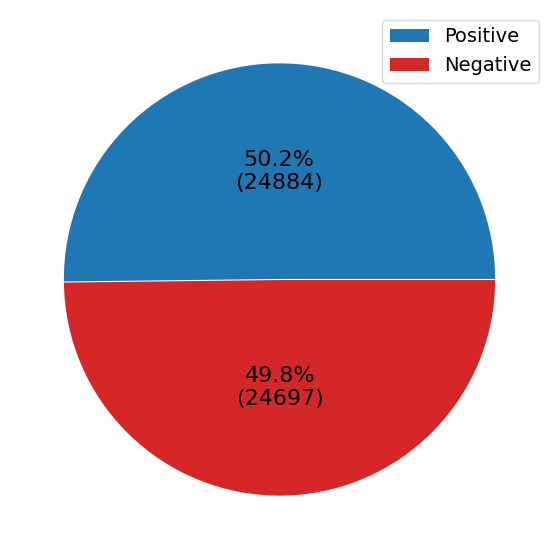

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Creating autocpt arguments
def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d})".format(pct, absolute)

freq_pos = len(df[df['sentiment'] == 'positive'])
freq_neg = len(df[df['sentiment'] == 'negative'])

data = [freq_pos, freq_neg]

labels = ['positive', 'negative']
# Create pie chart
pie, ax = plt.subplots(figsize=[11,7])
plt.pie(x=data, autopct=lambda pct: func(pct, data), explode=[0.0025]*2,
    pctdistance=0.5, colors=[sns.color_palette()[0],'tab:red'],textprops={'fontsize': 16})
# plt.title('Frequencies of sentiment labels', fontsize=14, fontweight='bold')
labels = [r'Positive', r'Negative']
plt.legend(labels, loc="best", prop={'size': 14})
pie.savefig("PieChart.png")
plt.show()

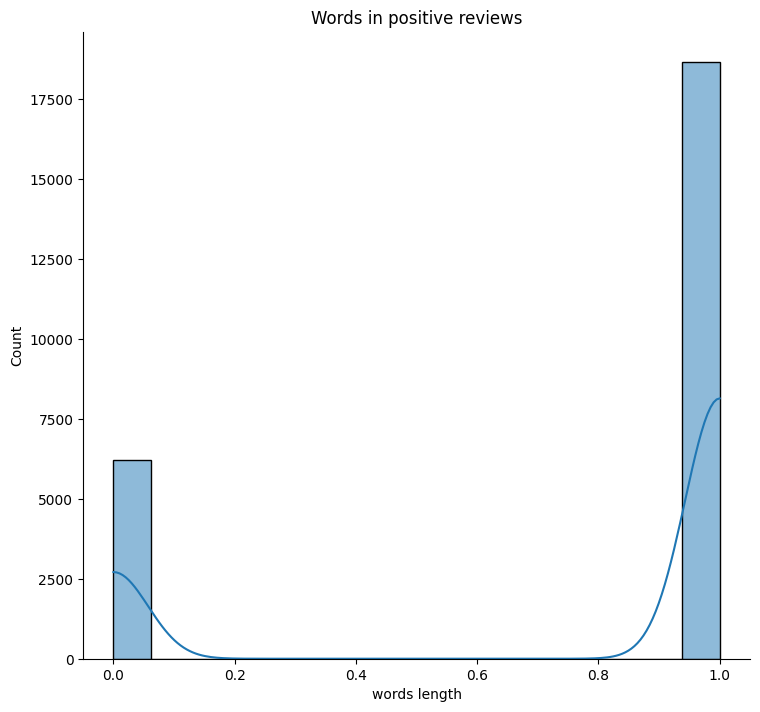

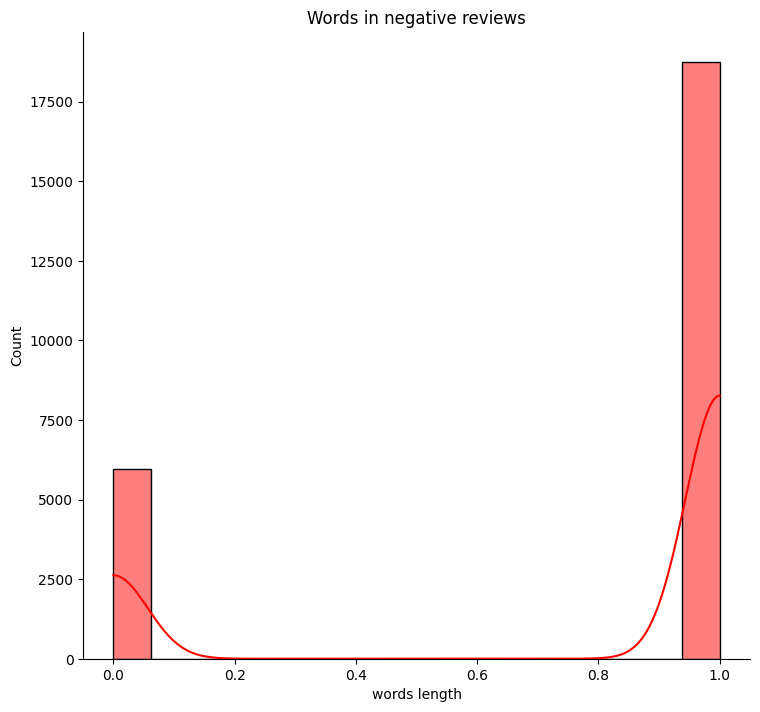

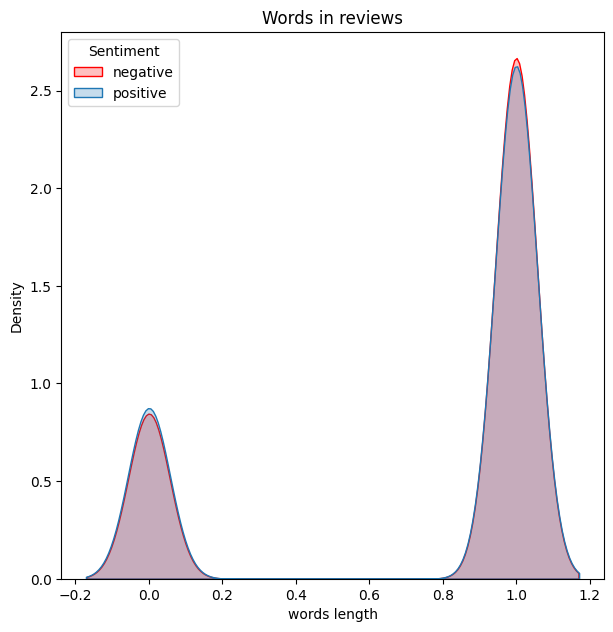

In [37]:
# thống kê độ dài các mẫu 
word_len = df['review'].str.split().map(lambda x : len(x))
df_temp = df.copy() 
df_temp['words length'] = word_len

hist_positive = sns.displot(
    data=df_temp[df_temp['sentiment'] == 'positive'],
    x="words length", hue="sentiment", kde=True, height=7, aspect=1.1, legend=False
).set(title='Words in positive reviews')
plt.show(hist_positive)

hist_negative = sns.displot(
    data=df_temp[df_temp['sentiment'] == 'negative'],
    x="words length", hue="sentiment", kde=True, height=7, aspect=1.1, legend=False, palette=['red']
).set(title='Words in negative reviews')
plt.show(hist_negative)

plt.figure(figsize=(7, 7.1))
kernel_distibution_number_words_plot = sns.kdeplot(
    data=df_temp, x="words length", hue="sentiment", fill=True, palette=[sns.color_palette()[0], 'red']
).set(title='Words in reviews')
plt.legend(title='Sentiment', labels=['negative', 'positive'])
plt.show(kernel_distibution_number_words_plot)

In [48]:
df.shape

(10050, 2)

In [41]:
# chia tập train và test 
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder 

label_encoder = LabelEncoder() 
y_data = label_encoder.fit_transform(df['sentiment'])
x_data = df['review']

x_train , x_test , y_train , y_test = train_test_split(
    x_data , y_data , 
    test_size = 0.2 , 
    random_state = 42 
) 


In [42]:
# biểu diễn văn bản thành vector 
tfidf_vectorizer = TfidfVectorizer(max_features = 10000)
tfidf_vectorizer.fit(x_train , y_train)

x_train_encoded = tfidf_vectorizer.transform(x_train)
x_test_encoded = tfidf_vectorizer.transform(x_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score

dt_classifier = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state = 42
)

dt_classifier.fit(x_train_encoded , y_train)
y_pred = dt_classifier.predict(x_test_encoded)
accuracy_score(y_test , y_pred)
# y_test là kết quả và đo độ chính xác giữa y_test và y_pred 

0.5961480286376929

In [44]:
rf_classifier = RandomForestClassifier(
    random_state = 42
)

rf_classifier = rf_classifier.fit(x_train_encoded , y_train)
y_pred = rf_classifier.predict(x_test_encoded)
accuracy_score(y_test , y_pred)

0.5945346374911767